<a href="https://colab.research.google.com/github/zamoralinokevin-eng/Maestria-en-IA/blob/main/Equipo_3_P2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 2: Análisis Exploratorio de Datos (EDA)
**Programación para Analítica Descriptiva y Predictiva** | Maestría en Inteligencia Artificial y Analítica de Datos | UACJ

**Equipo:** 3  
**Título del proyecto:** [Análisis Exploratorio de Datos Tasas de ocupación — INEGI]  
**Fecha de entrega:** 2026-10-07
**Integrantes:**

- 271753 Zamora Lino Kevin Josue
- 271756 Mendoza Enriquez Ari Daniel
- 271757 Sánchez Salas Sebastián Miguel


## 1. Portada y contribución del equipo

### 1.1 Integrantes y contribución


| Integrante | Responsabilidad principal | Apoyo en |
|---|---|---|
| Kevin Josue Zamora Lino | Notebook, Data profiling y limpieza | Preguntas |
| Ari Daniel Mendoza Enriquez | Presentación, Estadística descriptiva y visualizaciones | Notebook |
| Sebastian Miguel Sánchez Salas | Reporte, diccionario y preguntas | Presentación |

### 1.2 Entorno

In [62]:
# Librerías del proyecto (agregue las que use)
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42                      # semilla fija para cualquier proceso aleatorio
np.random.seed(SEED)

# Formato uniforme de gráficas para todo el notebook
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.grid.axis"] = "y"
plt.rcParams["grid.alpha"] = 0.3

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__, "| numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__, "| seaborn:", sns.__version__)

Python: 3.13.16
pandas: 2.2.3 | numpy: 2.1.3
matplotlib: 3.10.0 | seaborn: 0.13.2


## 2. Problema y preguntas de análisis

### 2.1 Fuente de los datos
- **Nombre del conjunto de datos:** Indicadores económicos de coyuntura. Tasas de Ocupación, desocupación y subocupación.
- **Fuente verificable (URL, repositorio o institución):**  https://inegi.org.mx/app/indicadores/?tm=3
Los datos provienene del INEGI, - Sistema de Consulta - Banco de Información Económica (BIE) - Indicadores económicos de coyuntura - Tasas de ocupación, desocupación y subocupación. La información fue recolectada previamente mediante la Encuesta nacional de Ocupación y Empleo (ENOE)
- **Licencia o condiciones de uso:** La información fue extraída del INEGI y es catalogada como datos de libre uso que pueden ser utilizados por cualquier persona sin cargo alguno. La información es usada como fines didácticos. El INEGI no se hace responsable de las interpretaciones o conclusiones que se extraigan de esta información
- **Fecha de consulta o descarga:** Los datos se exportaron el 31 de agosto del 2026 en formato .xlsx

### 2.2 Contexto del dominio
Cada registro representa el porcentaje de la población mexicana de 15 años y mas segun la situacion laboral específica como nivel de instrucción, posición en la ocupacion y sector de actividad económica. Los datos fueron recolectados desde Enero del 2005 hasta Julio del 2026. Para el estudiante de la maestria en Inteligencia Artificial y Analítica de Datos, este análisis es muy importante porque le permite comprender el comportamiento histórico y la tendencia laboral en México con herramientas de lectura, preprocesamiento, análisis estadístico y visualizacion de datos.

### 2.3 Preguntas de análisis


| # | Pregunta | Tipo (relación / comparación / distribución / otra) | Variables involucradas |
|---|---|---|---|
| P1 | ¿Cómo se distribuye históricamente el porcentaje de trabajadores por cuenta propia?  | Univariado | Porcentaje de ocupación de trabajadores por cuenta propia.  |
| P2 | ¿Cuál es la media de trabajadores que se dedican a la agricultura y ganadería?  | Univariado | Porcentaje de agricultura, ganadería, silvicultura, caza y pesca  |
| P3 | ¿Cuál es la relación entre el porcentaje de ocupados con medio superior y superior completo y el porcentaje de ocupados con primaria incompleta?  | Bivariado | Porcentaje con medio superior y superior, y porcentaje con primaria incompleta.  |
| P4 | ¿Que tipo de relación presenta el grupo de personas que se dedican a la industria de electricidad y manufacturera. ¿Cuál de los dos subgrupos mostró una mayor estabilidad?  | Multivariado | Porcentaje industria extractiva de la electricidad e industria manufacturera, Indicador de tiempo |
| P5 | ¿Como cambia la distribucion porcentual de la poblacion de trabajadores no remunerados a lo largo del tiempo?  | Bivariado | Porcentaje de población no remunerada, Indicador de tiempo.  |
| P6 | ¿Cómo cambia la distribución porcentual de la población ocupada entre los sectores primario, secundario y terciario a lo largo del tiempo?  | Multivariado | Porcentaje de población ocupada en los sectores primario, secundario y terciario, e indicador de tiempo. |

### 2.4 Variable objetivo candidata
- **Variable:** Porcentaje de Trabajadores subordinados y remunerados
- **Tipo de problema:** Regresion
- **Justificación:** La variable se ha capturado a lo largo del tiempo en un intervalo mensual, por lo que el modelo podria predecir el porcentaje de trabajadores subordinados en los proximos meses. Adicionamlmente, este indicador permite saber si la economía del país basada en empleos de sueldo que tienen patrón, es estable o fluctúa a lo largo del tiempo.

## 3. Descripción de los datos

### 3.1 Carga de los datos


In [63]:
#importamos el drive para leer el archivo con los datos
from google.colab import drive
drive.mount("/content/drive")

#se crea la ruta relativa para acceder al archivo de excel
DATA_PATH = "/content/drive/MyDrive/Entrega 02 - EDA/inegi2.xlsx"

# df_crudo no se modifica en ninguna celda posterior
df_crudo = pd.read_excel(DATA_PATH)

#se modifica el nombre de las columnas para hacerlo mas fácil de leer
valor_reemplazar = "Indicadores económicos de coyuntura > Tasas de ocupación, desocupación y subocupación (resultados mensuales de la ENOE, 15 años y más) > Series originales > Población total > Población ocupada > "
df_crudo.columns = df_crudo.columns.str.replace(valor_reemplazar, "", regex=False)
valor_2_reemplazar = "(Porcentaje) Mensual"
df_crudo.columns = df_crudo.columns.str.replace(valor_2_reemplazar, "", regex=False).str.strip()

#se imprimen las primeras filas del archivo leído
df_crudo.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Indicador,Por nivel de instrucción > Con primaria completa,Por nivel de instrucción > Con secundaria completa,Por nivel de instrucción > Medio superior y superior,Por nivel de instrucción > No especificado,Por nivel de instrucción > Primaria incompleta,Por posición en la ocupación > Empleadores,Por posición en la ocupación > No especificado,Por posición en la ocupación > Trabajadores no remunerados,Por posición en la ocupación > Trabajadores por cuenta propia,...,Por sector de actividad económica > Secundario > Industria manufacturera,Por sector de actividad económica > Secundario > Total,Por sector de actividad económica > Terciario > Comercio,Por sector de actividad económica > Terciario > Gobierno y organismos internacionales,Por sector de actividad económica > Terciario > Restaurantes y servicios de alojamiento,Por sector de actividad económica > Terciario > Servicios diversos,"Por sector de actividad económica > Terciario > Servicios profesionales, financieros y corporativos",Por sector de actividad económica > Terciario > Servicios sociales,Por sector de actividad económica > Terciario > Total,"Por sector de actividad económica > Terciario > Transportes, comunicaciones, correo y almacenamiento"
0,2005 Ene,22.535963,31.473101,24.646188,0.128427,21.21632,4.980670,0,7.137029,23.357850,...,67.456157,25.088920,33.567904,7.736105,9.913329,16.615907,9.552087,13.959044,58.980985,8.655624
1,2005 Feb,22.777991,30.922097,24.130252,0.069103,22.100557,4.810588,0,6.859435,23.821372,...,65.876657,25.758514,33.410909,7.731015,10.501498,17.412262,8.959747,13.566789,58.110525,8.417778
2,2005 Mar,23.155055,30.834649,24.79838,0.090742,21.121174,4.482183,0,7.553370,24.174376,...,66.286333,26.064497,33.484182,8.037796,9.923681,17.155810,8.842349,14.554895,59.014296,8.001285
3,2005 Abr,22.753796,31.057783,25.078696,0.130656,20.979069,4.959050,0,6.778941,23.934837,...,65.807547,25.612330,33.037215,7.908054,10.05352,16.243990,9.313439,14.62574,59.601524,8.818042
4,2005 May,23.253415,30.597212,24.219309,0.080496,21.849568,4.521417,0,7.198369,23.552478,...,66.469505,25.289566,33.841661,8.30132,10.189635,16.901420,9.288460,13.041477,58.777245,8.436027


### 3.2 Dimensiones y unidad de observación

In [64]:
#se imprimen las filas que tiene el dataset
print("Registros:", df_crudo.shape[0])

#se imprimen las columnas que tiene el dataset
print("Variables:", df_crudo.shape[1])

Registros: 259
Variables: 25


**Unidad de observación:**
Cada fila es una serie de tiempo con un indicador económico o laboral expresado en porcentaje que indica la cantidad de personas con esa característica respecto a la población total en México en ese tiempo.

### 3.3 Diccionario de datos
Una fila por variable del conjunto original.

| Variable | Tipo | Significado | Unidades / categorías posibles |
|---|---|---|---|
| Indicador | fecha | es el período mensual de la captura de datos | se expresa en año mes |
| Nivel de instrucción Primaria completa | numérica | expresa el porcentaje de la población con educación completa e incompleta | porcentaje en decimal |
| Nivel de instrucción Secundaria completa | numérica | expresa el porcentaje de la población con educación completa e incompleta | porcentaje en decimal |
| Nivel de instrucción Medio Superior y Superior | numérica | expresa el porcentaje de la población con educación completa e incompleta | porcentaje en decimal |
| Nivel de instrucción Primaria Incompleta | numérica | expresa el porcentaje de la población con educación completa e incompleta | porcentaje en decimal |
| Nivel de instrucción No especificado | numérica | expresa el porcentaje de la población con educación completa e incompleta | porcentaje en decimal |
| Por posición en la ocupación Empleadores | numérica | expresa el porcentaje de la población de trabajadores según la relación jerárquica en su empleo | porcentaje en decimal |
| Por posición en la ocupación Trabajadores por cuenta propia | numérica | expresa el porcentaje de la población de trabajadores según la relación jerárquica en su empleo | porcentaje en decimal |
| Por posición en la ocupación Trabajadores subordinados y remunerados | numérica | expresa el porcentaje de la población de trabajadores según la relación jerárquica en su empleo | porcentaje en decimal |
| Por posición en la ocupación Trabajadores no remunerados | numérica | expresa el porcentaje de la población de trabajadores según la relación jerárquica en su empleo | porcentaje en decimal |
| Por posición en la ocupación No especificado | numérica | expresa el porcentaje de la población de trabajadores según la relación jerárquica en su empleo | porcentaje en decimal |
| Por sector de actividad económica Primario (agricultura, ganadería, silvicultura, caza y pesca) | numérica | expresa el porcentaje de la población de acuerdo con la naturaleza de la empresa donde trabaja el empleado | porcentaje en decimal |
| Por sector de actividad económica Sector Secundario (construcción) | numérica | expresa el porcentaje de la población de acuerdo con la naturaleza de la empresa donde trabaja el empleado | porcentaje en decimal |
| Por sector de actividad económica Sector Secundario (industria extractiva y de la electricidad) | numérica | expresa el porcentaje de la población de acuerdo con la naturaleza de la empresa donde trabaja el empleado | porcentaje en decimal |
| Por sector de actividad económica Secundario (industria manufacturera) | numérica | expresa el porcentaje de la población de acuerdo con la naturaleza de la empresa donde trabaja el empleado | porcentaje en decimal |
| Por sector de actividad económica Secundario Total | numérica | expresa el porcentaje de la población de acuerdo con la naturaleza de la empresa donde trabaja el empleado | porcentaje en decimal |
| Por sector de actividad económica Terciario (comercio) | numérica | expresa el porcentaje de la población de acuerdo con la naturaleza de la empresa donde trabaja el empleado | porcentaje en decimal |
| Por sector de actividad económica Terciario (gobierno y organismos internacionales) | numérica | expresa el porcentaje de la población de acuerdo con la naturaleza de la empresa donde trabaja el empleado | porcentaje en decimal |
| Por sector de actividad económica Terciario (restaurantes y servicios de alojamiento) | numérica | expresa el porcentaje de la población de acuerdo con la naturaleza de la empresa donde trabaja el empleado | porcentaje en decimal |
| Por sector de actividad económica Terciario (servicios diversos) | numérica | expresa el porcentaje de la población de acuerdo con la naturaleza de la empresa donde trabaja el empleado | porcentaje en decimal |
| Por sector de actividad económica Terciario (servicios profesionales, financieros y corporativos) | numérica | expresa el porcentaje de la población de acuerdo con la naturaleza de la empresa donde trabaja el empleado | porcentaje en decimal |
| Por sector de actividad económica Terciario (servicios sociales)| numérica | expresa el porcentaje de la población de acuerdo con la naturaleza de la empresa donde trabaja el empleado | porcentaje en decimal |
| Por sector de actividad económica Terciario Total | numérica | expresa el porcentaje de la población de acuerdo con la naturaleza de la empresa donde trabaja el empleado | porcentaje en decimal |
| Por sector de actividad económica Terciario (transportes, comunicaciones, correo y almacenamiento)| numérica | expresa el porcentaje de la población de acuerdo con la naturaleza de la empresa donde trabaja el empleado | porcentaje en decimal |
| Por sector de actividad económica No especificado | numérica | expresa el porcentaje de la población de acuerdo con la naturaleza de la empresa donde trabaja el empleado | porcentaje en decimal |



## 4. Data profiling sobre los datos crudos


### 4.1 Tipos de dato

In [65]:
#se imprime la información de las variables con los tipos de dato usando info()
print("\nLa información general del dataframe es:")
print(df_crudo.info())


La información general del dataframe es:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259 entries, 0 to 258
Data columns (total 25 columns):
 #   Column                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                --------------  -----  
 0   Indicador                                                                                             259 non-null    object 
 1   Por nivel de instrucción > Con primaria completa                                                      259 non-null    object 
 2   Por nivel de instrucción > Con secundaria completa                                                    259 non-null    object 
 3   Por nivel de instrucción > Medio superior y superior                                                  259 non-null    object 
 4   Por nivel de instrucción > No especificado                    

**Interpretación:** ¿los tipos coinciden con el significado de cada variable? No coninciden los tipos de datos con las variables que contienen.
¿hay variables mal tipificadas? Sí. La variable "Indicador" debe ser tipo datetime y las demas variables deben ser de tipo float y varias estan actualmente como tipo Object

### 4.2 Valores faltantes (conteo, porcentaje y patrón)

In [66]:
#se imprimen los valores faltantes por columna, con la cantidad
#y el porcentaje antes del cambio del tipo de dato
faltantes_antes = df_crudo.isna().sum()
resumen_faltantes_antes = pd.DataFrame({"conteo": faltantes_antes, "porcentaje": (faltantes_antes / len(df_crudo) * 100).round(2)})
print(f"Los valores faltantes antes son:\n{resumen_faltantes_antes}")

#vamos a remplazar las variables tipo object por float para poner al descubierto valores faltantes
#se calculan los valores faltantes del dataframe por columna
faltantes_despues = df_crudo.isna().sum()
arreglo_columnas = [col for col in df_crudo.columns if col != "Indicador"]
for col in arreglo_columnas:
    df_crudo[col] = pd.to_numeric(df_crudo[col], errors='coerce').astype(float)


#se calculan los valores faltantes del dataframe por columna
faltantes_despues = df_crudo.isna().sum()

#se imprimen los valores faltantes por columna, con la cantidad y el porcentaje
resumen_faltantes_despues = pd.DataFrame({"conteo": faltantes_despues, "porcentaje": (faltantes_despues / len(df_crudo) * 100).round(2)})
print(f"\nLos valores faltantes despues son:\n{resumen_faltantes_despues.sort_values(by="conteo", ascending=False)}")


Los valores faltantes antes son:
                                                    conteo  porcentaje
Indicador                                                0         0.0
Por nivel de instrucción > Con primaria completa         0         0.0
Por nivel de instrucción > Con secundaria completa       0         0.0
Por nivel de instrucción > Medio superior y sup...       0         0.0
Por nivel de instrucción > No especificado               0         0.0
Por nivel de instrucción > Primaria incompleta           0         0.0
Por posición en la ocupación > Empleadores               0         0.0
Por posición en la ocupación > No especificado           0         0.0
Por posición en la ocupación > Trabajadores no ...       0         0.0
Por posición en la ocupación > Trabajadores por...       0         0.0
Por posición en la ocupación > Trabajadores sub...       0         0.0
Por sector de actividad económica > No especifi...       0         0.0
Por sector de actividad económica > Primario

In [67]:
#aprovechamos y reemplazamos el tipo de dato de la columna Indicador por un tipo datetime
#creamos un diccionario para mapear los meses en español a su número correspondiente
meses = {
    'Ene': '01', 'Feb': '02', 'Mar': '03', 'Abr': '04',
    'May': '05', 'Jun': '06', 'Jul': '07', 'Ago': '08',
    'Sep': '09', 'Oct': '10', 'Nov': '11', 'Dic': '12'
}

# Reemplazamos directamente la columna 'Indicador'
#debido a que la fecha no tiene el día, asimilamos que cada día del mes va a ser el 1
df_crudo['Indicador'] = pd.to_datetime(
    df_crudo['Indicador'].apply(lambda x: f"{x.split()[0]}-{meses[x.split()[1]]}-01" if isinstance(x, str) else x),
    errors='coerce'
)
#imprimimos el resultado de la conversión de los tipos de dato
print("El tipo de dato de cada columna después de la conversión es:")
print(df_crudo.info())
df_crudo.head()

El tipo de dato de cada columna después de la conversión es:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259 entries, 0 to 258
Data columns (total 25 columns):
 #   Column                                                                                                Non-Null Count  Dtype         
---  ------                                                                                                --------------  -----         
 0   Indicador                                                                                             259 non-null    datetime64[ns]
 1   Por nivel de instrucción > Con primaria completa                                                      256 non-null    float64       
 2   Por nivel de instrucción > Con secundaria completa                                                    256 non-null    float64       
 3   Por nivel de instrucción > Medio superior y superior                                                  256 non-null    float64       
 4   P

,Indicador,Por nivel de instrucción > Con primaria completa,Por nivel de instrucción > Con secundaria completa,Por nivel de instrucción > Medio superior y superior,Por nivel de instrucción > No especificado,Por nivel de instrucción > Primaria incompleta,Por posición en la ocupación > Empleadores,Por posición en la ocupación > No especificado,Por posición en la ocupación > Trabajadores no remunerados,Por posición en la ocupación > Trabajadores por cuenta propia,...,Por sector de actividad económica > Secundario > Industria manufacturera,Por sector de actividad económica > Secundario > Total,Por sector de actividad económica > Terciario > Comercio,Por sector de actividad económica > Terciario > Gobierno y organismos internacionales,Por sector de actividad económica > Terciario > Restaurantes y servicios de alojamiento,Por sector de actividad económica > Terciario > Servicios diversos,"Por sector de actividad económica > Terciario > Servicios profesionales, financieros y corporativos",Por sector de actividad económica > Terciario > Servicios sociales,Por sector de actividad económica > Terciario > Total,"Por sector de actividad económica > Terciario > Transportes, comunicaciones, correo y almacenamiento"
0,2005-01-01,22.535963,31.473101,24.646188,0.128427,21.216320,4.980670,0.0,7.137029,23.357850,...,67.456157,25.088920,33.567904,7.736105,9.913329,16.615907,9.552087,13.959044,58.980985,8.655624
1,2005-02-01,22.777991,30.922097,24.130252,0.069103,22.100557,4.810588,0.0,6.859435,23.821372,...,65.876657,25.758514,33.410909,7.731015,10.501498,17.412262,8.959747,13.566789,58.110525,8.417778
2,2005-03-01,23.155055,30.834649,24.798380,0.090742,21.121174,4.482183,0.0,7.553370,24.174376,...,66.286333,26.064497,33.484182,8.037796,9.923681,17.155810,8.842349,14.554895,59.014296,8.001285
3,2005-04-01,22.753796,31.057783,25.078696,0.130656,20.979069,4.959050,0.0,6.778941,23.934837,...,65.807547,25.612330,33.037215,7.908054,10.053520,16.243990,9.313439,14.625740,59.601524,8.818042
4,2005-05-01,23.253415,30.597212,24.219309,0.080496,21.849568,4.521417,0.0,7.198369,23.552478,...,66.469505,25.289566,33.841661,8.301320,10.189635,16.901420,9.288460,13.041477,58.777245,8.436027


**Interpretación:** ¿en qué variables faltan datos? Cuando se hizo el análisis con los datos tipos object, se mostro que en ninguna variable faltaban datos. Después de la conversión al tipo de datos float, varias categorías tenían valores nulos que habían sido registrados como cadena de texto.
¿hay un patrón (se concentran en un grupo, periodo o fuente)? Los valores nulos se observaron mayoritariamente en las variables relacionadas con el nivel de instrucción con una moda de 3 valores por categoría.
 ¿el faltante tiene significado propio? el faltante es resultado de la conversion de tipo de dato object a float.


### 4.3 Duplicados

In [68]:
print("Filas duplicadas completas:", df_crudo.duplicated().sum())

Filas duplicadas completas: 0


**Interpretación:** ¿los duplicados son errores o registros legítimos repetidos? No existen duplicados de filas completas

### 4.4 Cardinalidad y consistencia de categorías

In [69]:
#se calcula el conteo de valores únicos y cardinalidad por columna
reporte_cardinalidad = pd.DataFrame({
    'Valores Unicos': df_crudo.nunique(),
    'Cardinalidad %': round((df_crudo.nunique() / len(df_crudo)) * 100,2),
    'Tipo de Dato': df_crudo.dtypes
})

#se muestra el reporte con los valores de cardinalidad y tipo de dato en columnas individuales
reporte_cardinalidad.sort_values(by='Valores Unicos', ascending=False)


,Valores Unicos,Cardinalidad %,Tipo de Dato
Indicador,259,100.00,datetime64[ns]
Por posición en la ocupación > Trabajadores no remunerados,259,100.00,float64
Por posición en la ocupación > Empleadores,259,100.00,float64
Por sector de actividad económica > Secundario > Total,259,100.00,float64
Por sector de actividad económica > Secundario > Construcción,259,100.00,float64
"Por sector de actividad económica > Primario (agricultura, ganadería, silvicultura, caza y pesca)",259,100.00,float64
Por sector de actividad económica > No especificado,259,100.00,float64
Por posición en la ocupación > Trabajadores subordinados y remunerados,259,100.00,float64
Por posición en la ocupación > Trabajadores por cuenta propia,259,100.00,float64
Por sector de actividad económica > Terciario > Total,259,100.00,float64


**Interpretación:** Ninguna de estas columnas debe servir como variable categórica ya que presentan alta cardinalidad (>99%). Esto es debido a que son variables numéricas de tipo flotante que expresan un indicador económico en un determinado tiempo, no una categoría.

### 4.5 Rangos y valores plausibles

In [70]:
#se muestran varios valores estadísticos de cada columna
df_crudo.describe()

,Indicador,Por nivel de instrucción > Con primaria completa,Por nivel de instrucción > Con secundaria completa,Por nivel de instrucción > Medio superior y superior,Por nivel de instrucción > No especificado,Por nivel de instrucción > Primaria incompleta,Por posición en la ocupación > Empleadores,Por posición en la ocupación > No especificado,Por posición en la ocupación > Trabajadores no remunerados,Por posición en la ocupación > Trabajadores por cuenta propia,...,Por sector de actividad económica > Secundario > Industria manufacturera,Por sector de actividad económica > Secundario > Total,Por sector de actividad económica > Terciario > Comercio,Por sector de actividad económica > Terciario > Gobierno y organismos internacionales,Por sector de actividad económica > Terciario > Restaurantes y servicios de alojamiento,Por sector de actividad económica > Terciario > Servicios diversos,"Por sector de actividad económica > Terciario > Servicios profesionales, financieros y corporativos",Por sector de actividad económica > Terciario > Servicios sociales,Por sector de actividad económica > Terciario > Total,"Por sector de actividad económica > Terciario > Transportes, comunicaciones, correo y almacenamiento"
count,259,256.000000,256.000000,256.000000,256.000000,256.000000,259.000000,259.0,259.000000,259.000000,...,257.000000,259.000000,259.000000,257.000000,257.000000,259.000000,259.000000,257.000000,259.000000,257.000000
mean,2015-10-01 08:48:11.119691008,18.638469,33.082086,35.009208,0.082889,13.187347,4.809769,0.0,5.204153,22.502834,...,65.205528,24.837677,31.538140,7.352733,11.566918,16.764796,11.152814,13.291432,61.722891,8.318395
min,2005-01-01 00:00:00,13.395623,30.597212,24.016827,0.019099,7.301706,3.582879,0.0,1.965501,18.007832,...,60.570075,22.704127,26.081663,5.267185,9.134634,14.735755,8.568646,11.358954,57.798694,7.345238
25%,2010-05-16 12:00:00,15.733501,32.158758,28.956333,0.054429,9.200908,4.484986,0.0,4.224935,22.107614,...,64.475609,24.264676,30.866144,6.721814,10.683662,16.298673,10.324272,12.927845,60.921430,8.003935
50%,2015-10-01 00:00:00,18.958265,33.119876,33.851354,0.074643,12.783476,4.779961,0.0,5.104157,22.527973,...,65.340521,24.924404,31.402546,7.549637,11.584897,16.816846,11.269719,13.234680,61.714677,8.299733
75%,2021-02-15 00:00:00,21.196827,34.073915,41.453726,0.093869,16.480120,5.071974,0.0,6.302380,22.964803,...,66.018151,25.446130,32.178496,7.999255,12.506168,17.236430,12.009270,13.686162,62.693773,8.558758
max,2026-07-01 00:00:00,23.758110,35.071194,47.669269,0.261160,22.100557,6.476617,0.0,7.927892,24.641956,...,68.901079,26.701785,34.152299,12.300694,13.810674,18.292327,13.588561,15.162988,65.008836,9.768514
std,NaN,2.971738,1.132010,6.911506,0.043070,4.179967,0.490554,0.0,1.246992,0.815098,...,1.230047,0.812258,1.092782,0.904546,1.057535,0.638623,1.085664,0.546192,1.443800,0.416108


**Interpretación:** ¿hay valores imposibles o implausibles (negativos, fechas fuera de rango, ceros)? No existen valores negativos, imposibles o plausibles. El conteo coincide con el número de registros, ningún valor máximo es igual o mayor al 100%. La medida de tendencia central (media) no esta tan alejada del cuartil 2 (50%). Entre el cuartil 1 y 3, los datos presentan una distribución estrecha, el rango de cada columna no es amplio, lo que indica que los datos no están muy dispersos.

### 4.6 Valores atípicos

In [71]:
#filtramos las columnas para no contar la primera que son fechas
arreglo_columnas = [col for col in df_crudo.columns if col != "Indicador"]

#se procede a convertir las columnas object a float para el análisis estadístico
df_analisis = df_crudo.copy()
for col in arreglo_columnas:
    df_analisis[col] = pd.to_numeric(df_crudo[col], errors='coerce')

resultados = []
#se realiza el cálculo de Q1, Q3, IQR, límite superior, límite inferior y outliers
for col in arreglo_columnas:

    q1 = df_analisis[col].quantile(0.25)       # Primer Cuartil (Percentil 25)
    mediana = df_analisis[col].quantile(0.50)  # Mediana (Percentil 50)
    q3 = df_analisis[col].quantile(0.75)       # Tercer Cuartil (Percentil 75)
    iqr = q3 - q1
    limite_superior = q3 + 1.5 * iqr
    outliers = (df_analisis[col] > limite_superior).sum()

    #se crea la estructura del diccionario con los datos
    resultados.append({
    'Variable': col,
    'Valores Atípicos': outliers,
    'Cuartil 1 (Q1)': round(q1, 4),
    'Mediana (Q2)': round(mediana, 4),
    'Cuartil 3 (Q3)': round(q3, 4),
    'Rango Intercuartílico (IQR)': round(iqr, 4),
    'Límite Superior': round(limite_superior, 4)
    })

#se crea un dataframe para reportar los resultados de atipicos de manera ordenada
df_reporte = pd.DataFrame(resultados)
df_reporte = df_reporte.sort_values(by="Valores Atípicos", ascending=False)

#se muestra el reporte final del analisis estadistico de dispersion de los datos
print("Reporte de quartil 1, quartil 3, rango intercuartilico, limite superior y outliers")
print(df_reporte.to_string(index=False))

Reporte de quartil 1, quartil 3, rango intercuartilico, limite superior y outliers
                                                                                            Variable  Valores Atípicos  Cuartil 1 (Q1)  Mediana (Q2)  Cuartil 3 (Q3)  Rango Intercuartílico (IQR)  Límite Superior
                                                          Por nivel de instrucción > No especificado                18          0.0544        0.0746          0.0939                       0.0394           0.1530
                                                          Por posición en la ocupación > Empleadores                 9          4.4850        4.7800          5.0720                       0.5870           5.9525
Por sector de actividad económica > Terciario > Transportes, comunicaciones, correo y almacenamiento                 4          8.0039        8.2997          8.5588                       0.5548           9.3910
          Por sector de actividad económica > Secundario > Industria extr

**Interpretación:** ¿en qué variables hay atípicos y cuántos? Existen atípicos en las variables "Por nivel de instrucción > No especificado" con 18 valores atípicos, "Por posición en la ocupación > Empleadores" con 9 valores atípicos y otras categorías que presentan desde 4 hasta 1 valor atípico como se muestra en la parte de arriba.
 ¿son errores o valores extremos legítimos? Son valores extremos legítimos porque ninguno esta próximo al 100% y están dentro de un rango de dispersión de datos corto.


### 4.7 Resumen de problemas de calidad detectados

| # | Problema | Variable(s) | Magnitud | Gravedad (alta / media / baja) |
|---|---|---|---|---|
| 1 | variable "Indicador" con tipo de dato incorrecto | Indicador | fecha | baja, el valor estaba bien declarado, pero era de tipo Object Se reemplazo por el tipo datetime |
| 2 | Otras variables con tipo de dato incorrecto | la mayoría, excepto Indicador | Porcentaje | baja, el valor estaba bien declarado, pero era de tipo Object. Se reemplazo por el tipo float|
| 3 | Aparición de valores nulos después del cambio de tipo de dato | la mayoría, excepto Indicador | Porcentaje | baja, el valor no pudo ser capturado pero la dispersión de datos es pequeña. Se considera imputación por mediana |


## 5. Limpieza y transformación


In [72]:
#creamos una copia del dataframe antes de hacer la imputación de los nulos
df_limpio = df_crudo.copy()

### 5.1 Registro de decisiones

| # | Problema (de la tabla 4.7) | Decisión | Justificación con evidencia | Efecto (filas / valores afectados) |
|---|---|---|---|---|
| 1 | Aparición de valores nulos después del cambio de tipo de dato| Imputación con la mediana | La mediana es una métrica robusta que ignora valores extremos, asegurando que el dato imputado no afecte considerablemente otras métricas | Ya No aparecieron valores nulos en las columnas |


### 5.2 Aplicación de las decisiones

In [73]:
#Decisión #1  de la tabla 5.1
#Nota: las otras acciones se hicieron previamente debido al requierimiento del reporte
#estas acciones previas sólo consistieron en el cambio de tipo de dato de las columnas

#eliminamos la columna indicador y generamos un arreglo
columnas_validas = df_limpio.columns.drop('Indicador')

#realizamos el proceso de imputación con la mediana
df_limpio[columnas_validas] = df_limpio[columnas_validas].fillna(df_limpio[columnas_validas].median())

#verificamos la cantidad de nulos en cada columna
print("La cantidad de valores nulos por columna son:")
print(df_limpio.isna().sum())

La cantidad de valores nulos por columna son:
Indicador                                                                                               0
Por nivel de instrucción > Con primaria completa                                                        0
Por nivel de instrucción > Con secundaria completa                                                      0
Por nivel de instrucción > Medio superior y superior                                                    0
Por nivel de instrucción > No especificado                                                              0
Por nivel de instrucción > Primaria incompleta                                                          0
Por posición en la ocupación > Empleadores                                                              0
Por posición en la ocupación > No especificado                                                          0
Por posición en la ocupación > Trabajadores no remunerados                                              0


### 5.3 Comparación antes/después

In [74]:
#se comparan valores faltantes antes y después de la imputación de nulos
comparacion = pd.DataFrame({
    "antes": [df_crudo.shape[0], df_crudo.shape[1], df_crudo.isna().sum().sum()],
    "después": [df_limpio.shape[0], df_limpio.shape[1], df_limpio.isna().sum().sum()]
}, index=["filas", "columnas", "valores faltantes"])
comparacion

#se imprime la comparación de valores nulos antes y despues de la imputación con mediana
print(comparacion)

#se calcula la media antes de la imputación
media_antes = df_crudo[columnas_validas].mean()

#se calcula la media despues de la imputación
media_despues = df_limpio[columnas_validas].mean()

#se cra un dataframe con la comparativa de valores y la diferencia entre ambos
comparativa_medias = pd.DataFrame({
    'Media Antes': media_antes,
    'Media Después': media_despues,
    'Diferencia Absoluta': (media_despues - media_antes).abs()
})

comparativa_medias

                   antes  después
filas                259      259
columnas              25       25
valores faltantes     27        0


,Media Antes,Media Después,Diferencia Absoluta
Por nivel de instrucción > Con primaria completa,18.638469,18.642174,0.003704
Por nivel de instrucción > Con secundaria completa,33.082086,33.082524,0.000438
Por nivel de instrucción > Medio superior y superior,35.009208,34.995797,0.013411
Por nivel de instrucción > No especificado,0.082889,0.082793,0.000096
Por nivel de instrucción > Primaria incompleta,13.187347,13.182669,0.004678
Por posición en la ocupación > Empleadores,4.809769,4.809769,0.000000
Por posición en la ocupación > No especificado,0.000000,0.000000,0.000000
Por posición en la ocupación > Trabajadores no remunerados,5.204153,5.204153,0.000000
Por posición en la ocupación > Trabajadores por cuenta propia,22.502834,22.502834,0.000000
Por posición en la ocupación > Trabajadores subordinados y remunerados,67.483243,67.483243,0.000000


**Interpretación:** ¿cuánta información se perdió o se modificó? Se modificaron 27 valores faltantes en total mediante imputación con la mediana.
¿cambiaron las distribuciones de las variables clave? Se realizo un análisis de la media de cada columna antes y después de la imputación con mediana, se mostraron valores cercanos en la media de ambos dataframes con una diferencia absoluta menor a 0.02 en el peor escenario. No se mostró la comparativa de la mediana porque es la misma en ambos.



## 6. Estadística descriptiva
### 6.1 Variables numéricas: tendencia central, dispersión y forma

In [75]:
columnas_num = df_limpio.select_dtypes(include="number").columns

#se generan funciones de agregación para mostrar los valores estadísticos
resumen = df_limpio[columnas_num].agg(["mean", "median", "std", "min", "max", "skew", "kurt"]).T

#se muestra la tabla con las medidas estadísticas
resumen

,mean,median,std,min,max,skew,kurt
Por nivel de instrucción > Con primaria completa,18.642174,18.958265,2.954608,13.395623,23.758110,-0.091446,-1.227495
Por nivel de instrucción > Con secundaria completa,33.082524,33.119876,1.125416,30.597212,35.071194,-0.248231,-1.009720
Por nivel de instrucción > Medio superior y superior,34.995797,33.851354,6.872327,24.016827,47.669269,0.216670,-1.159513
Por nivel de instrucción > No especificado,0.082793,0.074643,0.042828,0.019099,0.261160,1.884609,4.254029
Por nivel de instrucción > Primaria incompleta,13.182669,12.783476,4.155819,7.301706,22.100557,0.391812,-1.005598
Por posición en la ocupación > Empleadores,4.809769,4.779961,0.490554,3.582879,6.476617,0.666289,1.007677
Por posición en la ocupación > No especificado,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Por posición en la ocupación > Trabajadores no remunerados,5.204153,5.104157,1.246992,1.965501,7.927892,0.001808,-1.061054
Por posición en la ocupación > Trabajadores por cuenta propia,22.502834,22.527973,0.815098,18.007832,24.641956,-1.248649,4.983772
Por posición en la ocupación > Trabajadores subordinados y remunerados,67.483243,67.936832,1.661613,63.233146,74.700718,-0.100943,0.652994


**Interpretación:** ¿media y mediana difieren? La media y la mediana si difieren pero muy poco lo que orienta que puede existir una desviacion pequeña de los datos hacia la derecha o la izquierda ¿qué indican la asimetría y la curtosis sobre la forma de cada distribución? Existen columnas con asimetria (Skew) ligeramente negativa, lo que indica que la distribucion de los datos tiene un sesgo hacia la izquierda, tambien existe skew positivo indicando que los datos tambien tienen un sesgo hacia la derecha. Referente a la curtosis, la mayoria presenta valores negativos lo que significa que es platicurtica con los datos dispersos de manera uniforme y baja presencia de outliers. Una menor cantidad presenta valores de curtosis mayores a cero, indicando que es leptocurtica, con mayor outliers.


### 6.2 Variables categóricas: frecuencias y moda

In [76]:
#df_limpio["variable_categorica"].value_counts(normalize=True).round(3)
print("No aplica el análisis de variables categóricas porque el dataframe no presenta este tipo de columnas, las variables son numéricas de tipo float")

No aplica el análisis de variables categóricas porque el dataframe no presenta este tipo de columnas, las variables son numéricas de tipo float


### 6.3 Estadística por subgrupos relevantes

In [77]:
# df_limpio.groupby("variable_categorica")["variable_numerica"].agg(["count", "mean", "median", "std"])
print("No aplica el análisis de variables categóricas porque el dataframe no presenta este tipo de columnas, las variables son numéricas de tipo float")

No aplica el análisis de variables categóricas porque el dataframe no presenta este tipo de columnas, las variables son numéricas de tipo float


**Interpretación:** No aplica para este dataframe debido a que las columnas no tienen valores categóricos, son valores numéricos que representan la población con propiedades características.

## 7. EDA orientado a preguntas


### 7.1 Pregunta P1: ¿Cómo se distribuye históricamente el porcentaje de trabajadores por cuenta propia?

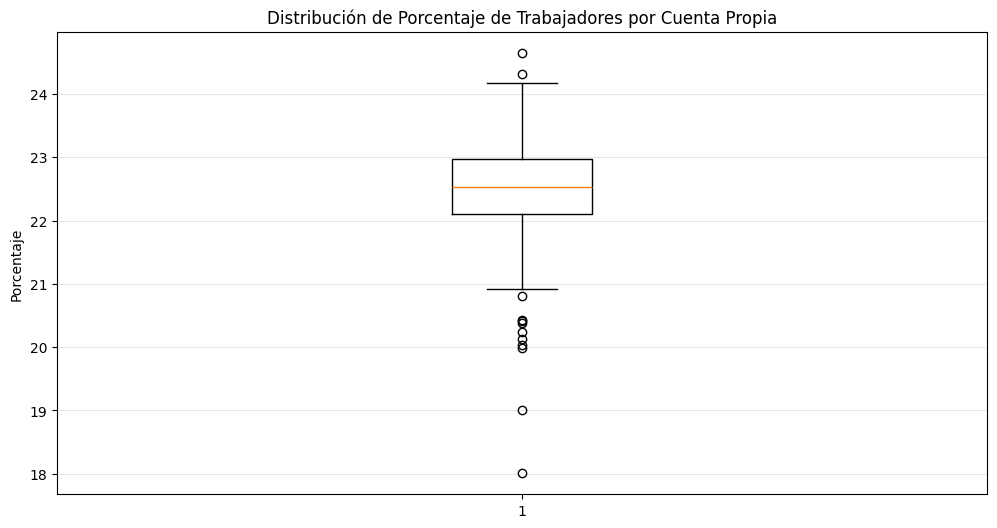

In [78]:
plt.figure(figsize=(12, 6))
#se selecciona histograma para ver la distribución de los datos
plt.boxplot(df_limpio["Por posición en la ocupación > Trabajadores por cuenta propia"])
#se agregan características a la gráfica como título y labels
plt.title("Distribución de Porcentaje de Trabajadores por Cuenta Propia")
plt.ylabel("Porcentaje")
#se muestra la gráfica
plt.show()


**Interpretación de la gráfica:** Se procedió a graficar un diagrama de caja para ver la distribución de los datos. Se observa que la mayor frecuencia de datos esta entre el 22 y 23% con outliers en el 18 y 21% y arriba de 24%. Esta distribución esta sesgada hacia la izquierda por lo que el valor que se calculó anteriormente de skew= -1.248649 concuerda con la gráfica. El valor de kurt = 4.983772 nos mostró en la gráfica que en efecto existen outliers

**Conclusión para P1:** El poder calcular medidas de dispersión y saber interpretarlas nos ayuda a tener una idea de cómo van a estar dispersos los datos al momento de graficarlos. Se sugiere complementar la gráfica con un histograma para ver la distribución de datos hacia la izquierda.


### 7.2 Pregunta P2: ¿Cuál es la media de trabajadores que se dedican a la agricultura y ganadería?

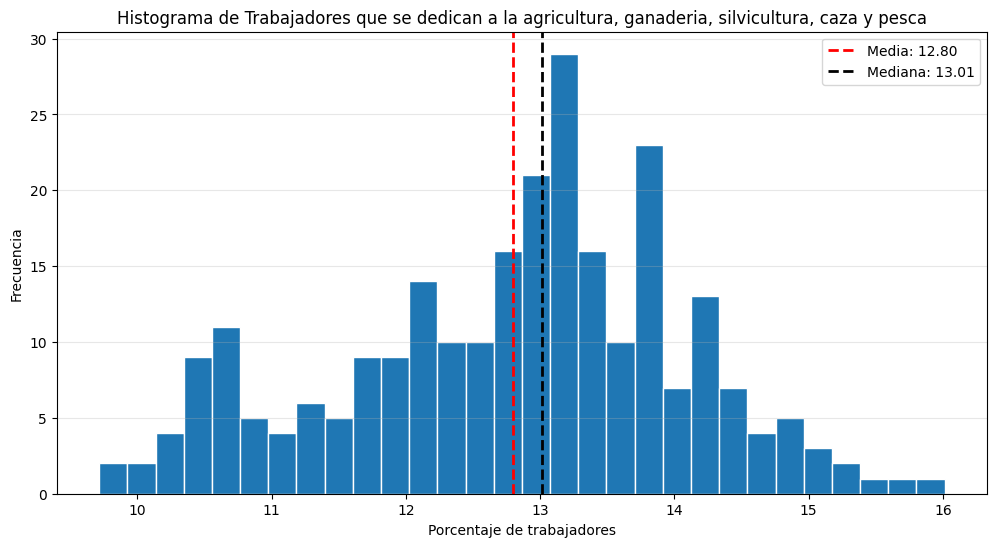

In [79]:
plt.figure(figsize=(12, 6))
#se selecciona el diagrama de caja para ver la distribución de los datos, media y outliers
columna_estudio = "Por sector de actividad económica > Primario (agricultura, ganadería, silvicultura, caza y pesca)"
media = df_limpio[columna_estudio].mean()
mediana = df_limpio[columna_estudio].median()

#se crea el histograma con la información
plt.hist(df_limpio[columna_estudio],
         bins=30,
         edgecolor="white")
#se agregan características a la gráfica como título y labels
plt.title("Histograma de Trabajadores que se dedican a la agricultura, ganaderia, silvicultura, caza y pesca")
plt.xlabel("Porcentaje de trabajadores")
plt.ylabel("Frecuencia")
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='black', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.legend()
#se muestra la gráfica
plt.show()

**Interpretación de la gráfica:** Como se había calculado previamente, esta categoría no presenta outliers y los datos se encuentran distribuidos uniformemente. La media de trabajadores que se dedican a esta actividad es de 12.8%. Se graficó la mediana para ver la comparativa entre ambos. Debido a que la media es ligeramente menor a la mediana, los datos están distribuidos más hacia la izquierda (12.8 media vs 13.01 mediana)

**Conclusión para P2:** La media como medida de tendencia central es útil pero cuando se puede comparar con la mediana en datos dispersos porque mientras más separadas estén unas de otras, más dispersión de los datos con presencia de outliers. Dependiendo de donde este ubicada la media respecto a la mediana, es el sentido de dispersión. En este caso la población estudio no presenta una dispersión significativa pero se considera que la mediana de 13.01% es la que mejor representa el conjunto de datos.


### 7.3 Pregunta P3: ¿Cuál es la relación entre el porcentaje de ocupados con medio superior y superior completo y el porcentaje de ocupados con primaria incompleta?

/tmp/ipykernel_3511/2214731519.py:8: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(


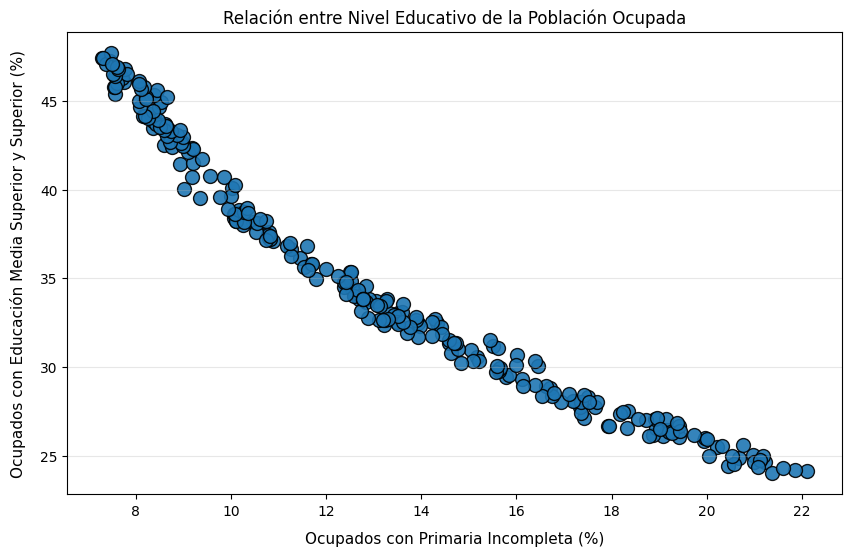

In [80]:
plt.figure(figsize=(10, 6))
#se agragan variables para las columnas estudio
columna1_estudio = "Por nivel de instrucción > Primaria incompleta"
columna2_estudio = "Por nivel de instrucción > Medio superior y superior"


#se crea el diagrama de dispersión de ambas variables
scatter = plt.scatter(
    df_limpio[columna1_estudio],
    df_limpio[columna2_estudio],
    cmap="viridis",
    s=100,
    alpha=0.9,
    edgecolors="black",
    label="Puntos mensuales"
)

#se añaden propiedades y labels a la grafica
plt.title("Relación entre Nivel Educativo de la Población Ocupada")
plt.xlabel("Ocupados con Primaria Incompleta (%)", fontsize=11, labelpad=10)
plt.ylabel("Ocupados con Educación Media Superior y Superior (%)", fontsize=11, labelpad=10)
#se muestra la gráfica
plt.show()


**Interpretación de la gráfica:** La grafica muestra un diagrama de dispersión en que se analizan dos variables, la educación medio-superior completa y la primaria incompleta. Claramente se una correlación negativa por la pendiente de la curva lo que indica que existe una correlación en que mientras más porcentaje de personas no acaban la primaria, es menor la cantidad de personas que estudian un nivel superior.

**Conclusión para P3:** El diagrama de dispersión es una herramienta visual muy útil para ver si existe correlación entre 2 variables. En nuestro caso de estudio, la correlación fue evidente lo que plantea preguntas adicionales para saber por qué existe este tipo de correlación negativa.


### 7.4 Pregunta P4: ¿Qué tipo de relación presenta el grupo de personas que se dedican a la industria de electricidad y manufacturera? ¿Cual de los dos subgrupos mostró mayor estabilidad?

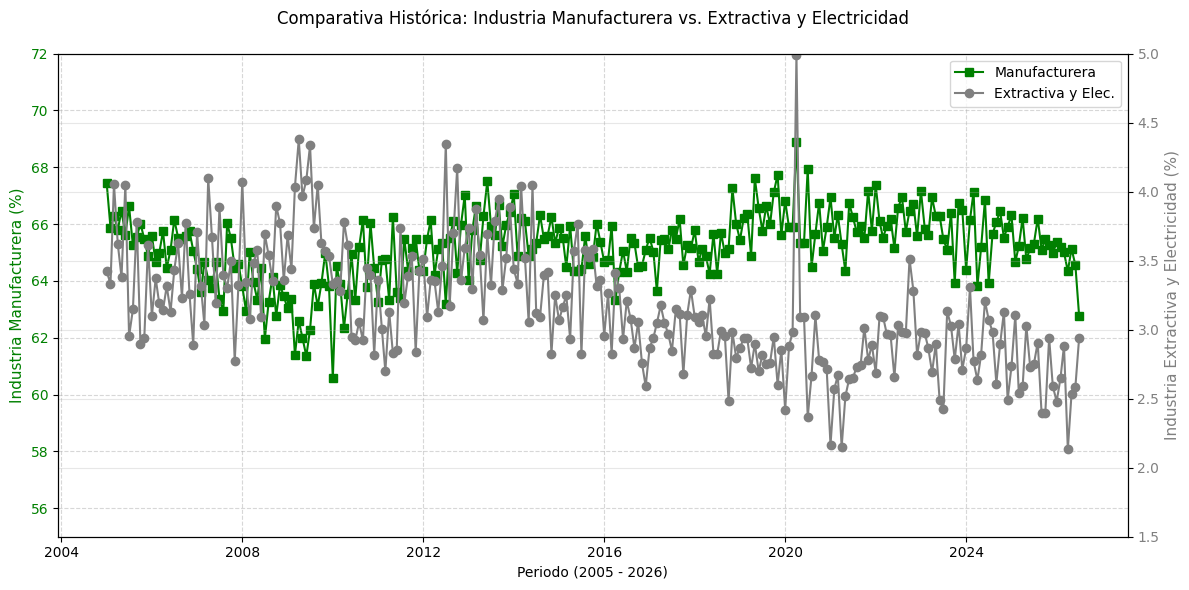

In [81]:
#variables de estudio
columna3_estudio = "Por sector de actividad económica > Secundario > Industria extractiva y de la electricidad"
columna4_estudio = "Por sector de actividad económica > Secundario > Industria manufacturera"

fig, ax1 = plt.subplots(figsize=(12, 6))

#se ingresan los datos de la primera gráfica
color_manu = "green"
ax1.set_xlabel('Periodo (2005 - 2026)')
ax1.set_ylabel('Industria Manufacturera (%)', color=color_manu, fontsize=11)
line1 = ax1.plot(df_limpio["Indicador"], df_limpio[columna4_estudio], color=color_manu, marker='s', label='Manufacturera')
ax1.tick_params(axis='y', labelcolor=color_manu)
ax1.set_ylim(55, 72)

ax2 = ax1.twinx()
#se ingresan los datos de la segunda gráfica
color_elec = "gray"
ax2.set_ylabel('Industria Extractiva y Electricidad (%)', color=color_elec, fontsize=11)
line2 = ax2.plot(df_limpio["Indicador"], df_limpio[columna3_estudio], color=color_elec, marker='o', label='Extractiva y Elec.')
ax2.tick_params(axis='y', labelcolor=color_elec)
ax2.set_ylim(1.5, 5.0)

#se muestran las leyendas de ambas gráficas
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('Comparativa Histórica: Industria Manufacturera vs. Extractiva y Electricidad\n')
ax1.grid(True, linestyle='--', alpha=0.5)

#se muestra la gráfica
plt.tight_layout()
plt.show()


**Interpretación de la gráfica:** La industria manufacturera ha presentado mayor estabilidad a lo largo del tiempo debido a las fluctuaciones no tan notorias. La industria de la electricidad ha presentado picos altos, pero también su rango de fluctuación es más alto
**Conclusión para P4:** la gráfica en la que se analizan 2 variables a lo largo del tiempo nos es útil para determinar cómo se han comportado estas en el intervalo especificado y como en la pregunta establecida, nos permite determinar los picos y valles y si se relacionan con alguna estación o periodo particular. Se sugiere analizar estos datos en intervalos específicos de tiempo.


### 7.5 Pregunta P5: ¿Cómo cambia la distribución porcentual de la población de trabajadores no remunerados a lo largo del tiempo?

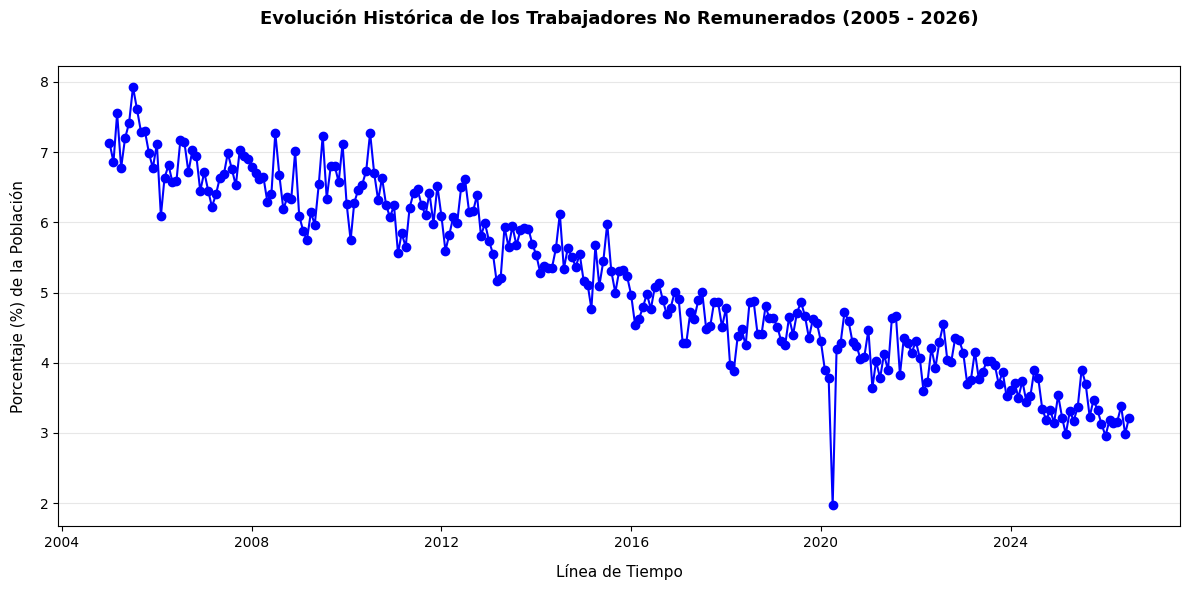

In [60]:
columna5_estudio = "Por posición en la ocupación > Trabajadores no remunerados"


plt.figure(figsize=(12, 6))

#se grafica la serie de tiempo
plt.plot(
    df_limpio["Indicador"],
    df_limpio[columna5_estudio],
    color='blue',
    linewidth=1.5,
    marker='o',
    markersize=6,
    label='Porcentaje de Ocupados No Remunerados')

#se agregan los títulos y labels
plt.title("Evolución Histórica de los Trabajadores No Remunerados (2005 - 2026)\n",
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Línea de Tiempo", fontsize=11, labelpad=10)
plt.ylabel("Porcentaje (%) de la Población", fontsize=11, labelpad=10)

#se muestran la gráfica
plt.tight_layout()
plt.show()

**Interpretación de la gráfica:** La serie de tiempo demuestra que a medida que pasan los meses, el porcentaje de población que trabaja y no recibe remuneración ha disminuido. Esto es un buen indicador económico para el país ya que demuestra que más trabajadores reciben un salario como parte de sus actividades a través del tiempo
**Conclusión para P5:** La serie de tiempo es la gráfica más sencilla para visualizar el comportamiento de una variable a través del tiempo, incluyendo las fluctuaciones, tendencia y los picos.


### 7.6 Pregunta P6: ¿Cómo cambia la distribución porcentual de la población ocupada entre los sectores primario, secundario y terciario a lo largo del tiempo?

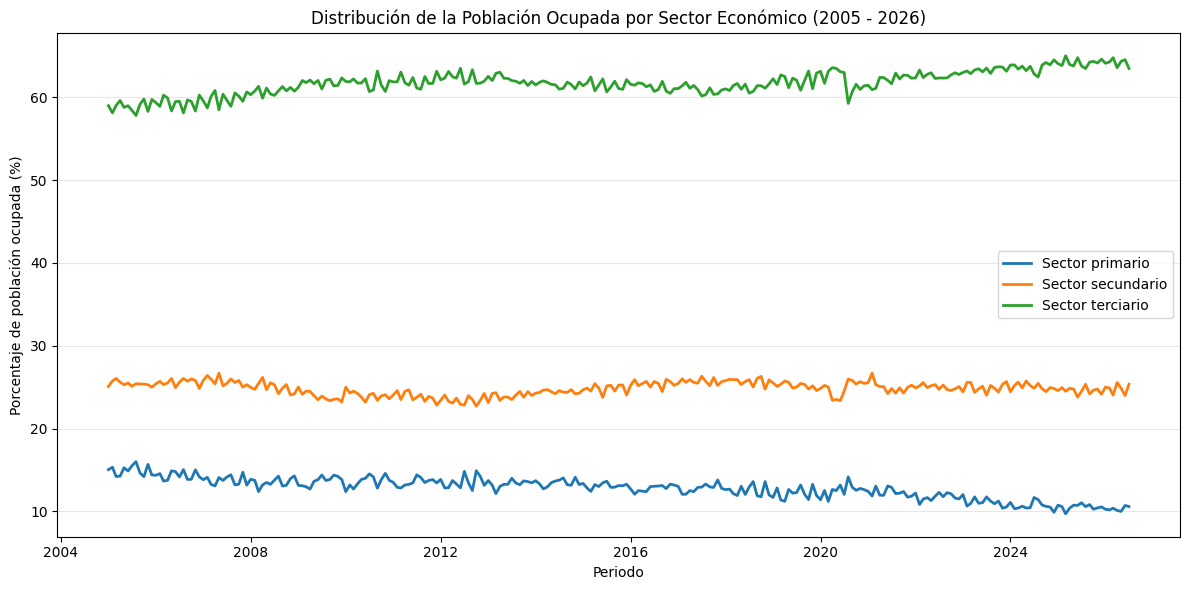

Sector primario: 15.05% -> 10.59%
Sector secundario: 25.09% -> 25.36%
Sector terciario: 58.98% -> 63.47%


In [61]:
#variables de estudio
columna_primario = "Por sector de actividad económica > Primario (agricultura, ganadería, silvicultura, caza y pesca)"
columna_secundario = "Por sector de actividad económica > Secundario > Total"
columna_terciario = "Por sector de actividad económica > Terciario > Total"

#se crea la gráfica para comparar los tres sectores a lo largo del tiempo
plt.figure(figsize=(12, 6))

plt.plot(df_limpio["Indicador"], df_limpio[columna_primario],
         linewidth=2, label="Sector primario")
plt.plot(df_limpio["Indicador"], df_limpio[columna_secundario],
         linewidth=2, label="Sector secundario")
plt.plot(df_limpio["Indicador"], df_limpio[columna_terciario],
         linewidth=2, label="Sector terciario")

#se agregan título, etiquetas y leyenda
plt.title("Distribución de la Población Ocupada por Sector Económico (2005 - 2026)")
plt.xlabel("Periodo")
plt.ylabel("Porcentaje de población ocupada (%)")
plt.legend()
plt.tight_layout()
plt.show()

#se imprimen los valores iniciales y finales para apoyar la interpretación
print(f"Sector primario: {df_limpio[columna_primario].iloc[0]:.2f}% -> {df_limpio[columna_primario].iloc[-1]:.2f}%")
print(f"Sector secundario: {df_limpio[columna_secundario].iloc[0]:.2f}% -> {df_limpio[columna_secundario].iloc[-1]:.2f}%")
print(f"Sector terciario: {df_limpio[columna_terciario].iloc[0]:.2f}% -> {df_limpio[columna_terciario].iloc[-1]:.2f}%")

**Interpretación de la gráfica:** La gráfica muestra cambios en la distribución de la población ocupada entre los tres sectores económicos a lo largo del periodo analizado. El sector primario pasó de 15.05% en enero de 2005 a 10.59% en julio de 2026, mientras que el sector terciario pasó de 58.98% a 63.47%. Por otro lado, el sector secundario inició en 25.09% y terminó en 25.36%, mostrando un cambio menor entre el inicio y el final del periodo.

**Conclusión para P6:** Durante el periodo analizado se observa una disminución en la participación del sector primario y un aumento en la del sector terciario, mientras que el sector secundario termina en un nivel similar al inicial. Esto permite identificar cambios en la composición de la población ocupada por sector económico, aunque el análisis descriptivo no permite determinar las causas de estas variaciones.

## 8. Hallazgos y limitaciones

### 8.1 Respuesta resumida a cada pregunta

| Pregunta | Respuesta | Evidencia (sección / gráfica) |
|---|---|---|
| P1 | El porcentaje de trabajadores por cuenta propia se concentra principalmente alrededor de 22% a 23%, con algunos valores atípicos. | [7.1] |
| P2 | El promedio de población ocupada en el sector primario es de aproximadamente 12.8%, con una mediana cercana a 13.01%. | [7.2] |
| P3 | La gráfica sugiere una relación negativa entre el porcentaje con primaria incompleta y el porcentaje con educación media superior y superior. | [7.3] |
| P4 | La industria manufacturera presenta mayor estabilidad, mientras que la industria extractiva y de la electricidad muestra mayores fluctuaciones. | [7.4] |
| P5 | El porcentaje de trabajadores no remunerados presenta una tendencia general a disminuir a lo largo del periodo analizado. | [7.5] |
| P6 | El sector primario pasa de 15.05% a 10.59%, mientras que el terciario pasa de 58.98% a 63.47%. El sector secundario termina en un nivel muy similar al inicial, pasando de 25.09% a 25.36%. | [7.6] |

### 8.2 Limitaciones y sesgos de los datos
- El dataframe utilizado para este análisis contiene principalmente indicadores de la población ocupada, por lo que no permite analizar directamente la desocupación y la subocupación con las variables cargadas en el notebook.
- Los datos se encuentran agregados a nivel nacional, por lo que no permiten identificar diferencias entre estados, municipios o personas de manera individual.
- Se imputaron 27 valores faltantes utilizando la mediana. Aunque el efecto sobre las medias fue pequeño, esta decisión puede reducir algunas variaciones puntuales de los datos.
- El análisis es descriptivo y permite identificar patrones y relaciones, pero no permite afirmar que una variable sea la causa de los cambios observados.

## 9. Declaración de uso de IA y referencias

### 9.1 Declaración de uso de IA
| Herramienta | Para qué tarea se usó | Cómo se verificó el resultado |
|---|---|---|
| Google Gemini | Optimización de gráficas | se escribió el código para incluir sugerencias de optimización de gráficas |

### 9.2 Referencias
- Página oficial del INEGI
